# Mapping the Parks

Using data from [nycopendata](https://nycopendata.socrata.com/Recreation/Parks-Properties/enfh-gkve/about_data), specifically the `shape` column, let's see if we can create map visualizations.

In [1]:
import datetime
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.eda import COLORS, COLORS_DICT, get_parks_data, PARKS_MAPPING, nymyc_cmap, nymyc_cmap_r, read_all_csvs

# mpl.colormaps.register(cmap=nymyc_cmap)
# mpl.colormaps.register(cmap=nymyc_cmap_r)
# nymyc_palette = sns.set_palette(sns.color_palette(COLORS))

# Show all columns in DataFrames
pd.set_option('display.max_columns', None)

# Auto-reload modules
%load_ext autoreload
%autoreload 2

<Axes: >

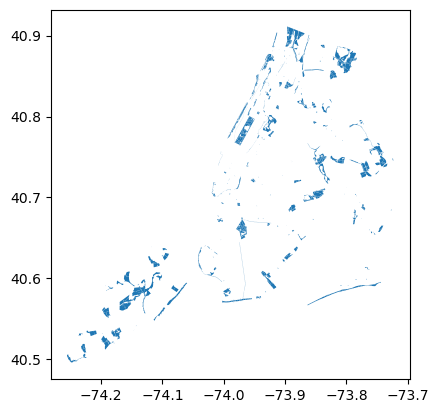

In [2]:
parks = gpd.read_file('../data/Parks Zones_20241027/')
parks.plot()

Got it plotting! But definitely need borough boundaries or something else in the background--can't just have parks floating in space.

<Axes: >

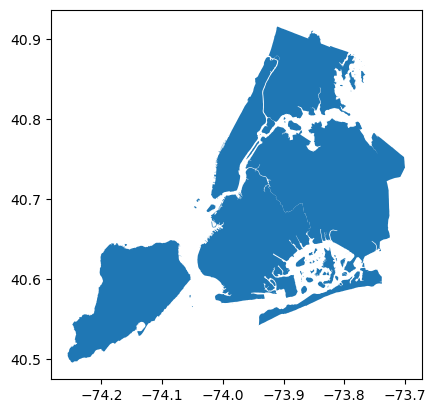

In [3]:
boroughs = gpd.read_file('../data/Borough Boundaries/')
boroughs.plot()

Now to combine them...

<Axes: >

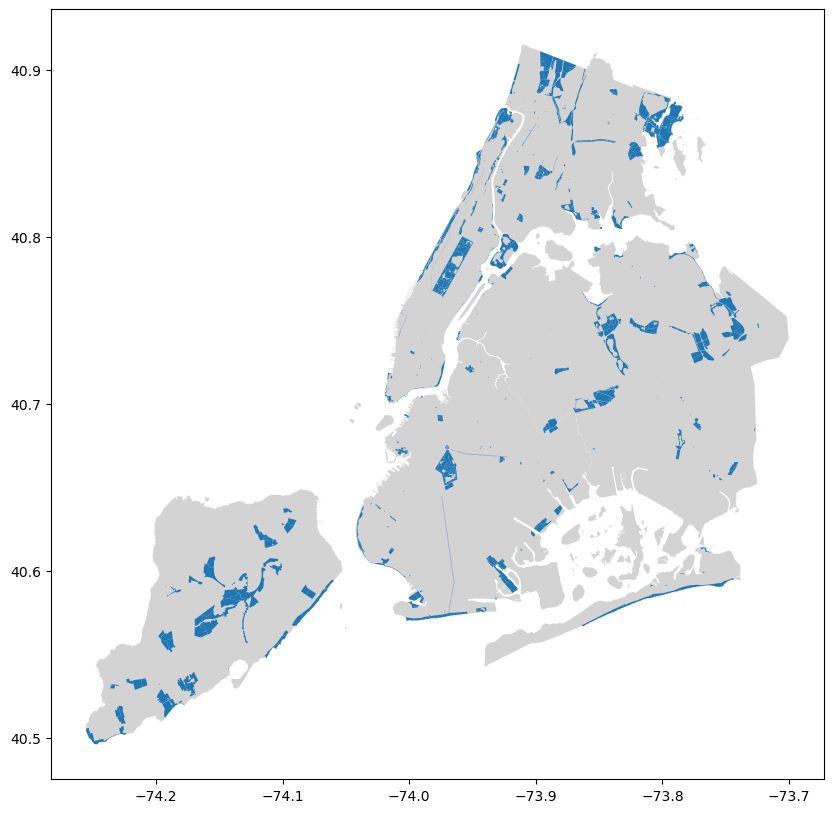

In [4]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks.plot(ax=ax)

Success! Now to get some data in there...

In [5]:
parks_data = get_parks_data()
parks_data.head()

,MushroomID,NewToPark,NewToCity,ParkName,Borough,City,State,BroadGroupID,Genus,Species,BroadGroupName,FullName
0,300,y,y,Central Park,Manhattan,New York City,NY,3.0,Hortiboletus,campestris,Boletes,Hortiboletus campestris
1,2329,y,y,Central Park,Manhattan,New York City,NY,3.0,Boletus,subvelutipes-complex,Boletes,Boletus subvelutipes-complex
2,3,y,y,Central Park,Manhattan,New York City,NY,3.0,Cyanoboletus,pulverulentus,Boletes,Cyanoboletus pulverulentus
3,4,y,y,Central Park,Manhattan,New York City,NY,3.0,Gyroporus,castaneus,Boletes,Gyroporus castaneus
4,5,y,y,Central Park,Manhattan,New York City,NY,3.0,Tylopilus,ferrugineus,Boletes,Tylopilus ferrugineus


In [6]:
# Check for parks that don't match across datasets
nymyc_parks = list(parks_data['ParkName'].unique())
nymyc_parks.sort()
nyc_parks = list(parks['propname'].unique())
nyc_parks.sort()
print('Parks in walks list but not in NYC data:')
print([p for p in nymyc_parks if p not in nyc_parks])
print('\n')
print('Parks in NYC data but not in walks list:')
print([p for p in nyc_parks if p not in nymyc_parks])

Parks in walks list but not in NYC data:
['Beech Brook', 'Collis P. Huntingdon Park', 'Depew Park', "Devil's Den Preserve", 'Fahnestock State Park', 'Green-Wood Cemetery', 'High Rock Park', 'Manitou Point Preserve', 'Mt. Lakes Park', 'Norvin Green State Forest', 'Putnam Memorial State Park', 'South Mountain Reservation', 'Stony Brook, Harriman', 'Stony Brook, Long Island', 'Tallman State Park', 'Untermeyer Gardens', 'Wawayanda State Park', 'Woodlawn Cemetery']


Parks in NYC data but not in walks list:
['Alley Athletic Playground', 'Aqueduct Walk', 'Archie Spigner Park', 'Arden Woods', 'Asphalt Green', 'Asser Levy Park', 'Astoria Park', 'Bailey Playground', 'Baisley Pond Park', 'Battery Park City', 'Bayswater Park', 'Belt Parkway/Shore Parkway', 'Bensonhurst Park', 'Betsy Head Park', 'Blood Root Valley', 'Bloomingdale Park', 'Blue Heron Park', 'Bowne Park', 'Breukelen Ballfields', 'Broadway Malls', 'Bronx Park', 'Bronx River Parkway', 'Brookfield Park', 'Brooklyn Bridge Park', 'Brookvi

Looks like most of the parks from the walk list that aren't in NYC's data are, in fact, not in NYC. So no worries there. Others aren't NYC parks, like Woodlawn Cemetery.

The parks in NYC's data that aren't in the walks list are a lot of parks that just don't have walks (like Washington Sq Park).

There are some that just don't match up (like 'Randalls Island' vs 'Randall's Island Park' and 'Wolfe\\'s Pond Park' vs 'Wolfe's Pond Park'), so should clean those up. (Note: adding that to some of the cleaning functinality in `eda.py` that gets called whenever reading in the data.)

In [7]:
# Merge in geometry polygons
parks_counts = parks_data.groupby('ParkName')[['BroadGroupName','Species']].nunique().reset_index()
parks_counts = parks_counts.rename(columns={'BroadGroupName':'BroadGroupCounts',
                                            'Species':'SpeciesCounts'})
parks_counts

,ParkName,BroadGroupCounts,SpeciesCounts
0,Alley Pond Park,16,381
1,Beech Brook,17,386
2,Central Park,14,316
3,Clove Lakes Park,15,302
4,Collis P. Huntingdon Park,13,223
5,Conference House Park,2,2
6,Cunningham Park,15,364
7,Depew Park,12,185
8,Devil's Den Preserve,11,128
9,Fahnestock State Park,13,159


In [8]:
parks_viz = parks.merge(parks_counts, 
                        left_on='propname', right_on='ParkName', 
                        how='left')
parks_viz.head()

,acres,borough,communityb,councildis,department,descriptio,gispropnum,location,nys_assemb,nys_senate,omppropid,precinct,propname,retired,retireddat,sitename,subcategor,us_congres,zipcode,geometry,ParkName,BroadGroupCounts,SpeciesCounts
0,12.455131,M,164.0,6.0,M-13,Central Park-The Great Hill,M010,"N Of 105, E Of CPW, W Of West Dr, SE Of 106 Path",68,29,M010-ZN46,22.0,Central Park,F,None,None,None,13,10025.0,"POLYGON ((-73.95686 40.79685, -73.95683 40.796...",Central Park,14.0,316.0
1,19.992587,M,164.0,6.0,M-13,Central Park-East Meadow,M010,"East Drive, 97 St Transverse, 5 Ave, E 102 St ...","69, 68",29,M010-ZN38,22.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.95386 40.79063, -73.95389 40.790...",Central Park,14.0,316.0
2,6.451369,M,164.0,6.0,M-13,Central Park-North Meadow Recreation Center,M010,"W Drive, 97 St Transverse, N Meadow Recreation...","69, 68",29,M010-ZN36,2.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.96174 40.79158, -73.96172 40.791...",Central Park,14.0,316.0
3,15.300478,M,164.0,6.0,M-13,Central Park-79th St Yard And Summit Rock,M010,"CPW, 79 St Transverse, West Drive To 85 St","69, 67",29,M010-ZN29,2.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96932 40.78429, -73.96926 40.784...",Central Park,14.0,316.0
4,5.212581,M,164.0,6.0,M-13,Central Park-Reservoir Running Track & Landscape,M010,Mid-park In The 80's,69,29,M010-ZN31,4.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96320 40.78286, -73.96325 40.782...",Central Park,14.0,316.0


Interesting--many rows per park? Looks like multiple "zones" per park, but I bet that will show up in the viz as one contiguous area.

''

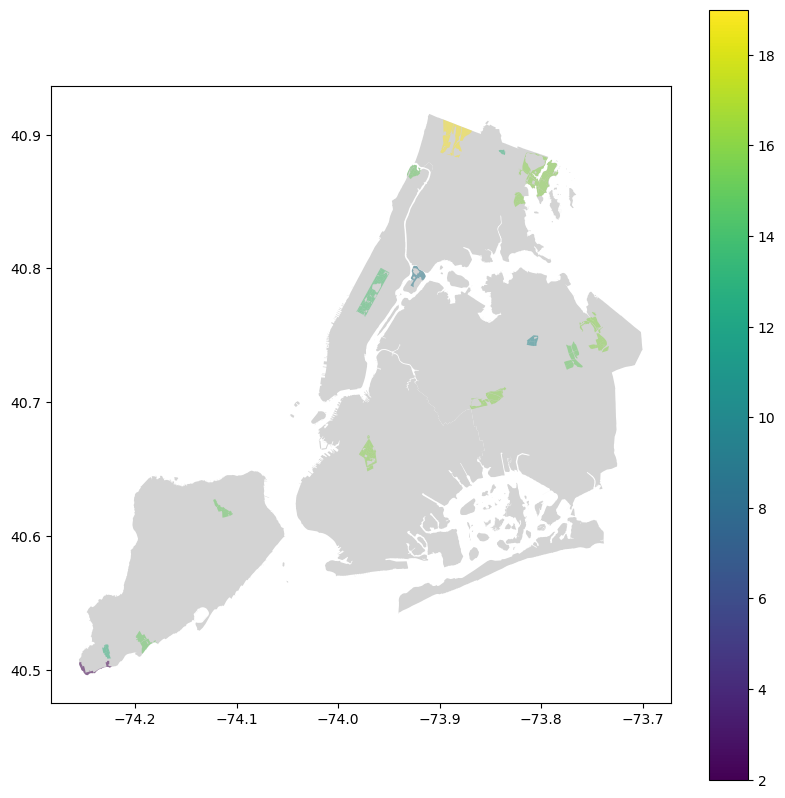

In [9]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks_viz.plot(column='BroadGroupCounts', ax=ax,
                  legend=True, alpha=.5)
plt.savefig('./img/parks_groups_counts.png')
;

''

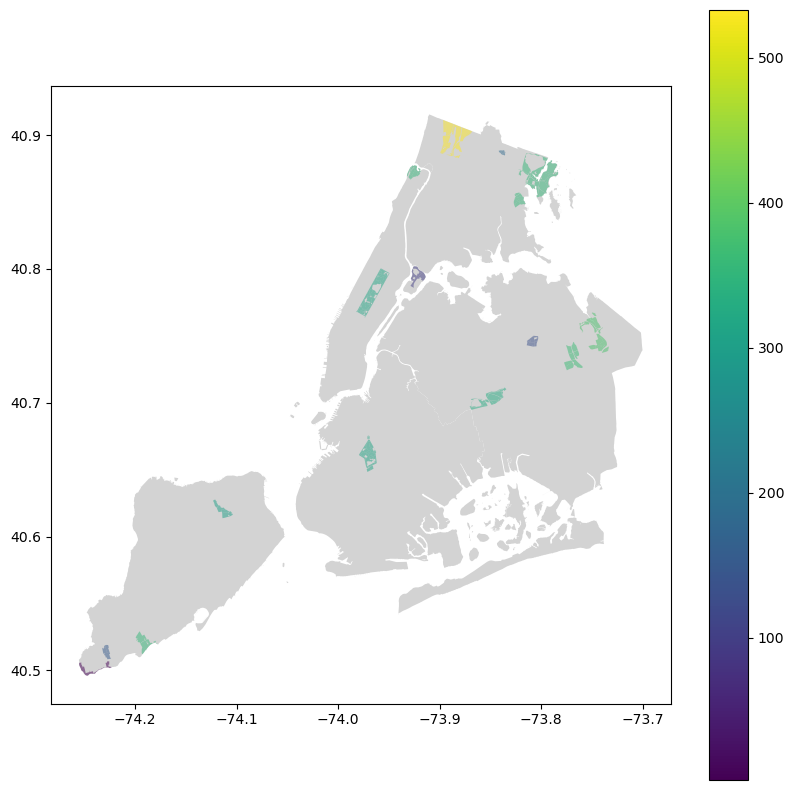

In [10]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks_viz.plot(column='SpeciesCounts', ax=ax,
                  legend=True, alpha=.5)
plt.savefig('./img/parks_species_counts.png')
;

Let's try visualizing each park separately to get better resolution.

''

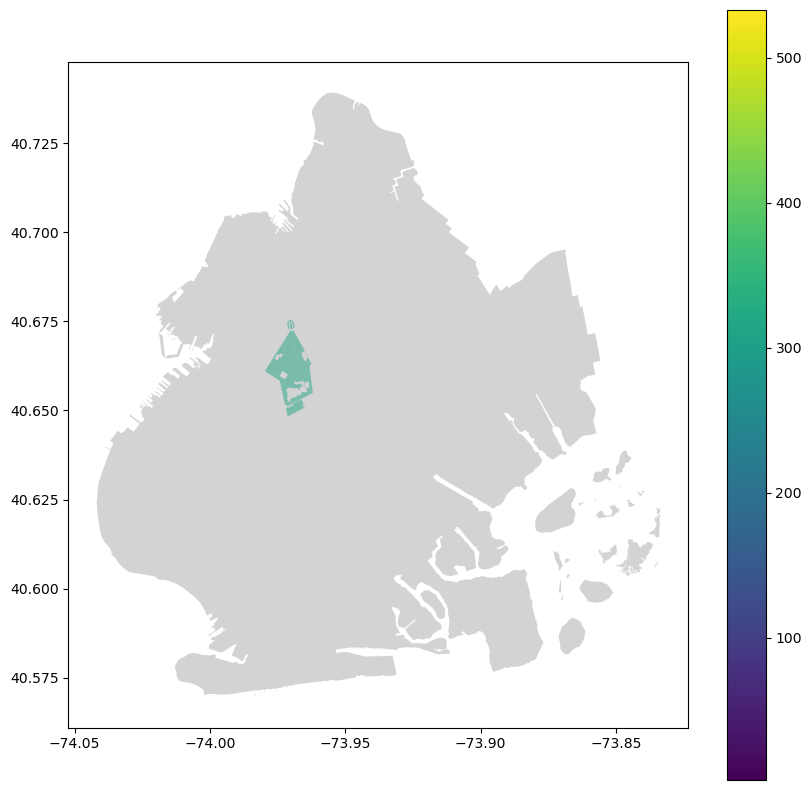

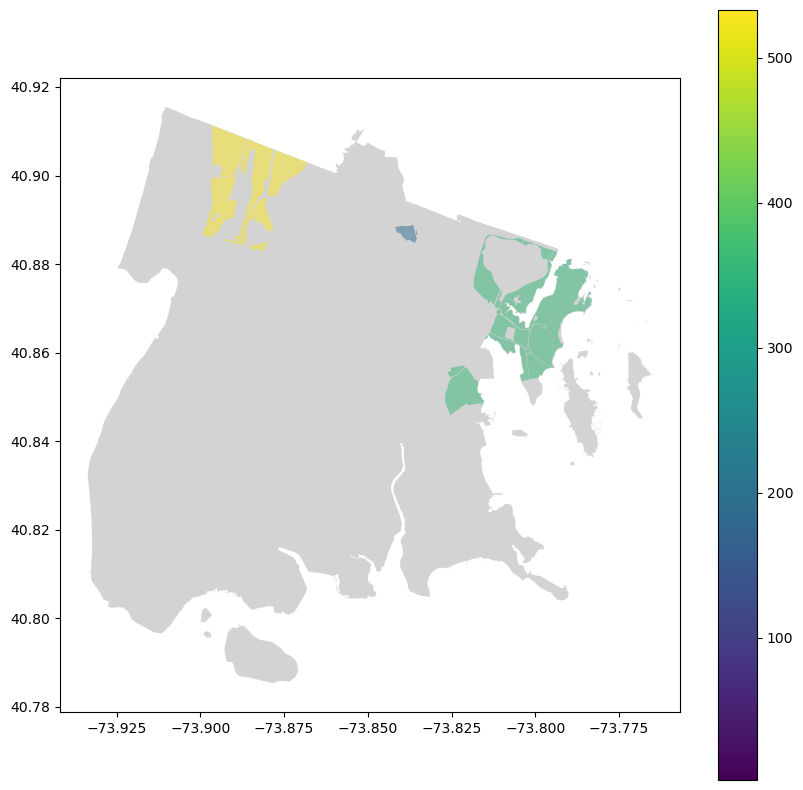

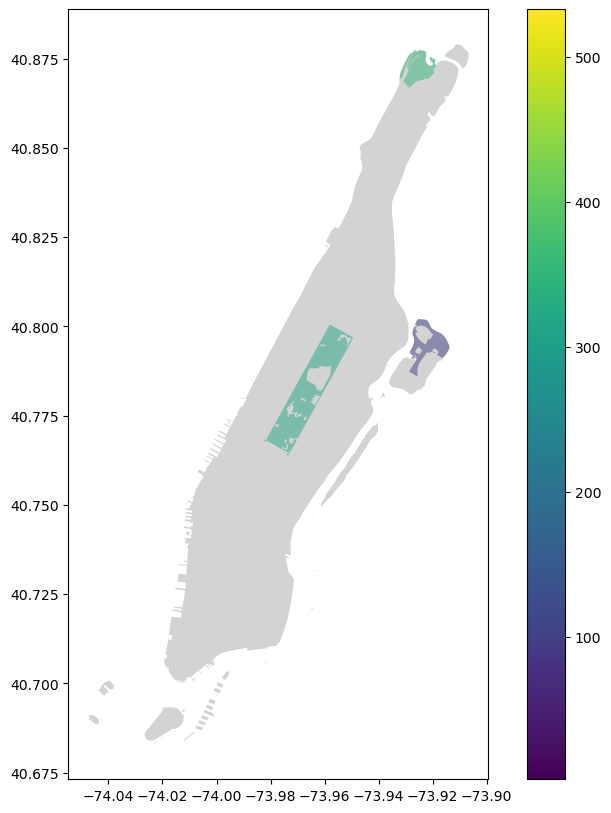

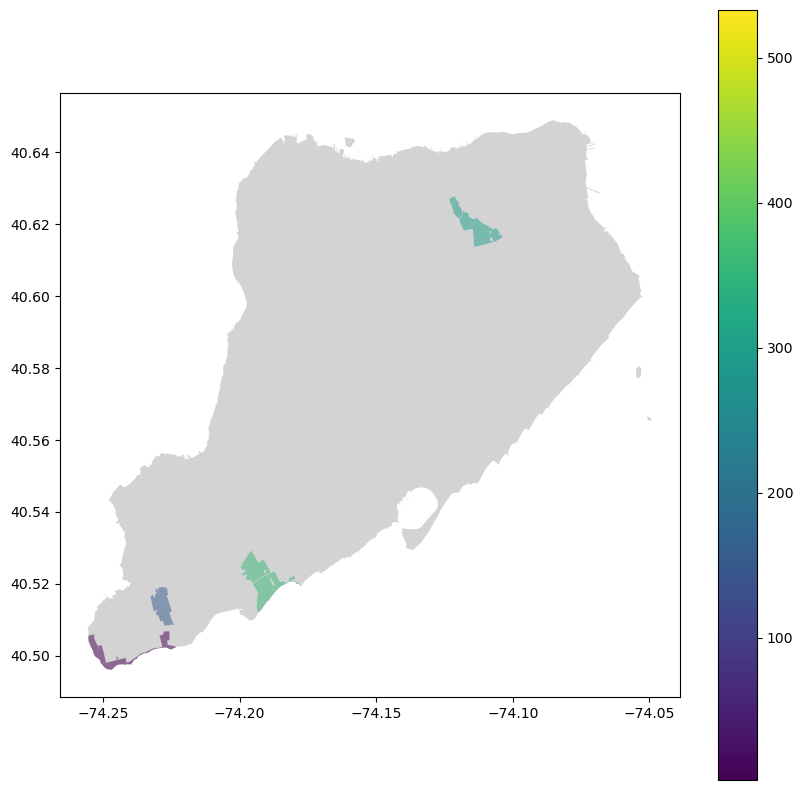

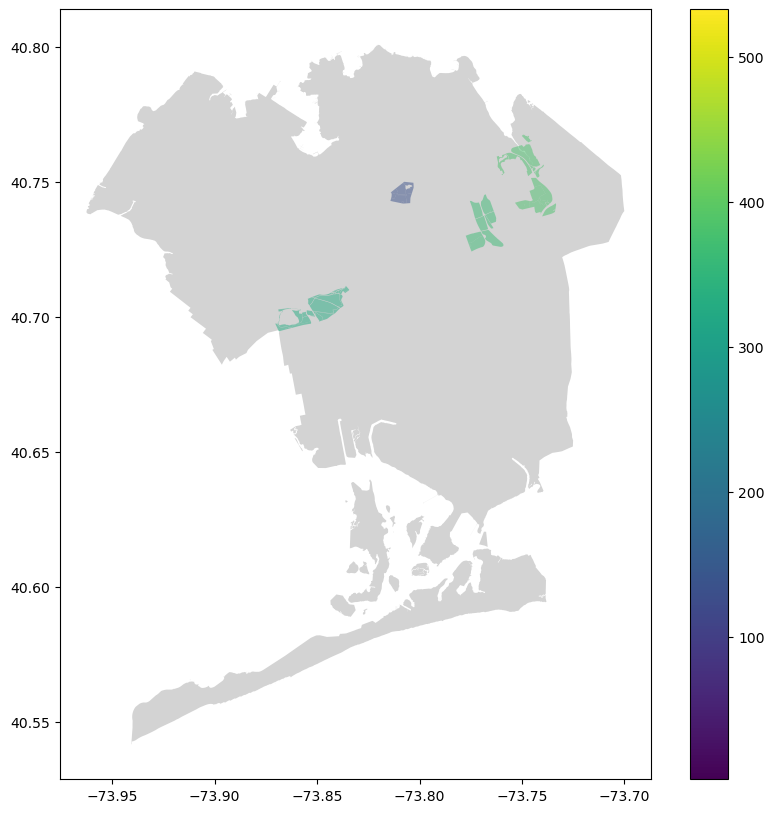

In [11]:
for b, boro in PARKS_MAPPING.items():
    fig, ax = plt.subplots(figsize=(10,10))
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesCounts', ax=ax, legend=True, 
                                                alpha=.5, vmin=parks_viz['SpeciesCounts'].min(),
                                                vmax=parks_viz['SpeciesCounts'].max())
    # print(ax._children[1].__dict__)
    # print(ax.__dict__)
    # print(dir(ax))
;

''

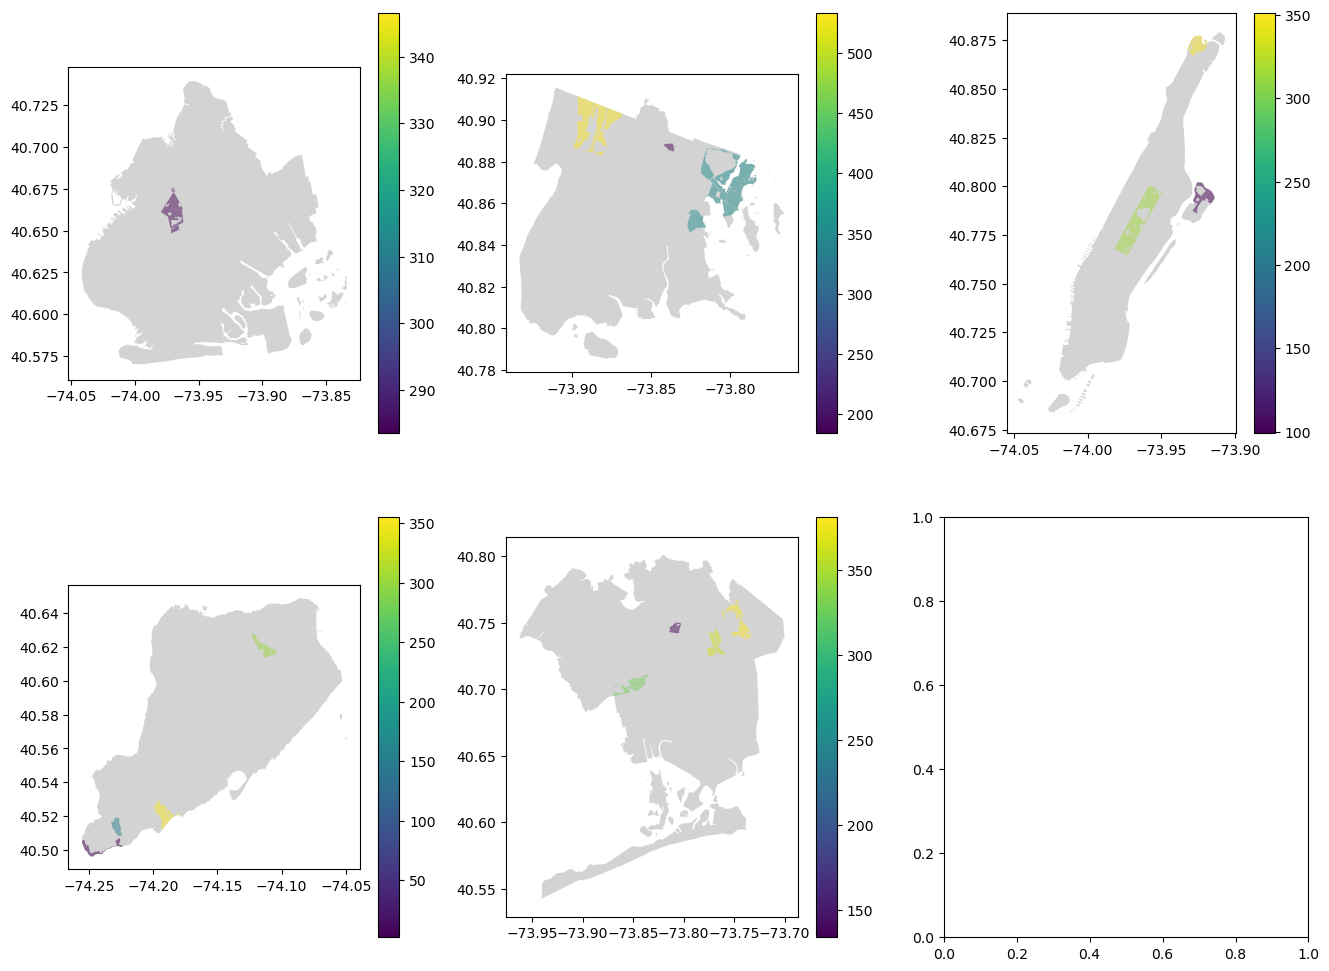

In [12]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesCounts', ax=ax,
                  legend=True, alpha=.5)
;

In [13]:
boroughs.loc[boroughs['boro_name']=='Brooklyn']

,boro_code,boro_name,shape_area,shape_leng,geometry
0,3.0,Brooklyn,1.934143e+09,728147.130565,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."


In [14]:
parks_viz.sample(20)

,acres,borough,communityb,councildis,department,descriptio,gispropnum,location,nys_assemb,nys_senate,omppropid,precinct,propname,retired,retireddat,sitename,subcategor,us_congres,zipcode,geometry,ParkName,BroadGroupCounts,SpeciesCounts
826,22.520656,M,164.0,6.0,M-13,Central Park-The Metropolitan Museum Of Art,M010,"East Drive, 79 St Transverse, 5th Ave To 86 St",69,29,M010-ZN26,2.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96240 40.78137, -73.96234 40.781...",Central Park,14.0,316.0
149,49.068631,Q,411.0,23.0,Q-07A,Alley Pond Park Zone 4,Q001,Natural Area: South Of North Paved Path Leadin...,"24, 25","16, 11",Q001-ZN04,111.0,Alley Pond Park,F,None,None,None,6,11364.0,"POLYGON ((-73.74184 40.74287, -73.74184 40.742...",Alley Pond Park,16.0,381.0
542,39.704109,B,318.0,46.0,B-18,Canarsie Park Zone 3,B018,"Paerdegat Basin, Belt Pkwy: Natural Area And W...",59,19,B018-ZN03,69.0,Canarsie Park,F,None,None,None,8,11236.0,"POLYGON ((-73.90026 40.62471, -73.90007 40.624...",NaN,NaN,NaN
392,18.482807,X,204.0,16.0,X-04,Claremont Park-Claremont Zone 1,X008,"Teller Av, Mt Eden Pkwy, Topping Av, E 172 St ...",77,33,X008-ZN01,44.0,Claremont Park,F,None,None,None,15,10457.0,"POLYGON ((-73.90592 40.84222, -73.90592 40.842...",NaN,NaN,NaN
474,26.209775,Q,412.0,28.0,Q-12,Baisley Pond Park Zone 5,Q005,"150th St, Rockaway Blvd, Baisley Blvd South, N...",32,10,Q005-ZN05,3.0,Baisley Pond Park,F,None,None,None,5,11434.0,"POLYGON ((-73.78770 40.67285, -73.78765 40.672...",NaN,NaN,NaN
610,0.676835,R,503.0,51.0,R-03,Bloomingdale Playground,None,"Ramona Ave, Lenevar Ave",62,24,R106-01,123.0,Bloomingdale Park,F,None,None,None,11,10309.0,"POLYGON ((-74.20830 40.53505, -74.20830 40.535...",NaN,NaN,NaN
833,28.474411,R,502.0,50.0,R-02,S.I. Greenbelt-Egbertville Ravine,R065,"London Rd To Richmond Rd, Rockland Ave To Comb...","62, 63",24,R065-ZN06,122.0,Richmond Parkway,F,None,None,None,11,10306.0,"MULTIPOLYGON (((-74.12925 40.57842, -74.12928 ...",NaN,NaN,NaN
30,41.015318,Q,407.0,20.0,Q-07,Kissena Park Zone 4,Q024,Booth Memorial Av Btw Kissena Blvd + 162nd St ...,25,11,Q024-ZN04,109.0,Kissena Park,F,None,None,None,6,11365.0,"POLYGON ((-73.81106 40.74527, -73.81099 40.745...",Kissena Park,10.0,134.0
73,62.798137,Q,481.0,24.0,Q-15,Flushing Meadows Park-Willow Lake,Q099,(n) 69th Rd To (e) Van Wyck Expwy To (w) GCP T...,27,"16, 15",Q099-ZN26,112.0,Flushing Meadows Corona Park,F,None,None,None,6,11367.0,"POLYGON ((-73.83298 40.72721, -73.83298 40.727...",NaN,NaN,NaN
891,18.772380,X,208.0,11.0,X-08,Riverdale Park Zone 1,X142,Hudson River From Spaulding La To W 254th St,81,34,X142-ZN01,50.0,Riverdale Park,F,None,None,None,16,10471.0,"POLYGON ((-73.91387 40.90379, -73.91386 40.903...",NaN,NaN,NaN


## Normalizing the data

Showing the number of species per park isn't super helpful since some parks are visited far more often than others. Let's try plotting the number of species *per walk*.

In [15]:
dfs = read_all_csvs('./data')
print(dfs.keys())

[*] Reading in Parks.csv...
[*] Reading in BroadGroups.csv...
[*] Reading in Parks_Properties_20241008.csv...
[*] Reading in Mushroom.csv...
[*] Reading in Walks.csv...
[*] Reading in Observations.csv...
dict_keys(['parks', 'broadgroups', 'parks_properties_20241008', 'mushroom', 'walks', 'observations'])


In [16]:
walk_counts = (dfs['walks']
               .groupby('ParkID')
               .count()[['WalkID']]
               .rename(columns={'WalkID':'WalkCounts'})
               .merge(dfs['parks'][['ParkID','ParkName']], on='ParkID')
              )
walk_counts.head()

,ParkID,WalkCounts,ParkName
0,11,47,Pelham Bay Park
1,12,34,High Rock Park
2,13,49,Prospect Park
3,14,10,Seton Falls Park
4,15,7,Kissena Park


In [17]:
parks_counts = parks_counts.merge(walk_counts, on='ParkName')
parks_counts

,ParkName,BroadGroupCounts,SpeciesCounts,ParkID,WalkCounts
0,Alley Pond Park,16,381,29,25
1,Beech Brook,17,386,30,8
2,Central Park,14,316,19,43
3,Clove Lakes Park,15,302,20,19
4,Collis P. Huntingdon Park,13,223,45,3
5,Conference House Park,2,2,43,1
6,Cunningham Park,15,364,26,37
7,Depew Park,12,185,35,5
8,Devil's Den Preserve,11,128,36,1
9,Fahnestock State Park,13,159,31,2


In [18]:
parks_counts['SpeciesPerWalk'] = parks_counts.apply(lambda x: round(x['SpeciesCounts']/x['WalkCounts'], 2), axis=1)
parks_counts.head()

,ParkName,BroadGroupCounts,SpeciesCounts,ParkID,WalkCounts,SpeciesPerWalk
0,Alley Pond Park,16,381,29,25,15.24
1,Beech Brook,17,386,30,8,48.25
2,Central Park,14,316,19,43,7.35
3,Clove Lakes Park,15,302,20,19,15.89
4,Collis P. Huntingdon Park,13,223,45,3,74.33


In [19]:
parks_viz = parks_viz.merge(parks_counts[['SpeciesPerWalk','WalkCounts','ParkName']], 
                            left_on='propname', right_on='ParkName', 
                            how='left').drop(['ParkName_x','ParkName_y'],axis=1)
parks_viz.head()

,acres,borough,communityb,councildis,department,descriptio,gispropnum,location,nys_assemb,nys_senate,omppropid,precinct,propname,retired,retireddat,sitename,subcategor,us_congres,zipcode,geometry,BroadGroupCounts,SpeciesCounts,SpeciesPerWalk,WalkCounts
0,12.455131,M,164.0,6.0,M-13,Central Park-The Great Hill,M010,"N Of 105, E Of CPW, W Of West Dr, SE Of 106 Path",68,29,M010-ZN46,22.0,Central Park,F,None,None,None,13,10025.0,"POLYGON ((-73.95686 40.79685, -73.95683 40.796...",14.0,316.0,7.35,43.0
1,19.992587,M,164.0,6.0,M-13,Central Park-East Meadow,M010,"East Drive, 97 St Transverse, 5 Ave, E 102 St ...","69, 68",29,M010-ZN38,22.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.95386 40.79063, -73.95389 40.790...",14.0,316.0,7.35,43.0
2,6.451369,M,164.0,6.0,M-13,Central Park-North Meadow Recreation Center,M010,"W Drive, 97 St Transverse, N Meadow Recreation...","69, 68",29,M010-ZN36,2.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.96174 40.79158, -73.96172 40.791...",14.0,316.0,7.35,43.0
3,15.300478,M,164.0,6.0,M-13,Central Park-79th St Yard And Summit Rock,M010,"CPW, 79 St Transverse, West Drive To 85 St","69, 67",29,M010-ZN29,2.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96932 40.78429, -73.96926 40.784...",14.0,316.0,7.35,43.0
4,5.212581,M,164.0,6.0,M-13,Central Park-Reservoir Running Track & Landscape,M010,Mid-park In The 80's,69,29,M010-ZN31,4.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96320 40.78286, -73.96325 40.782...",14.0,316.0,7.35,43.0


''

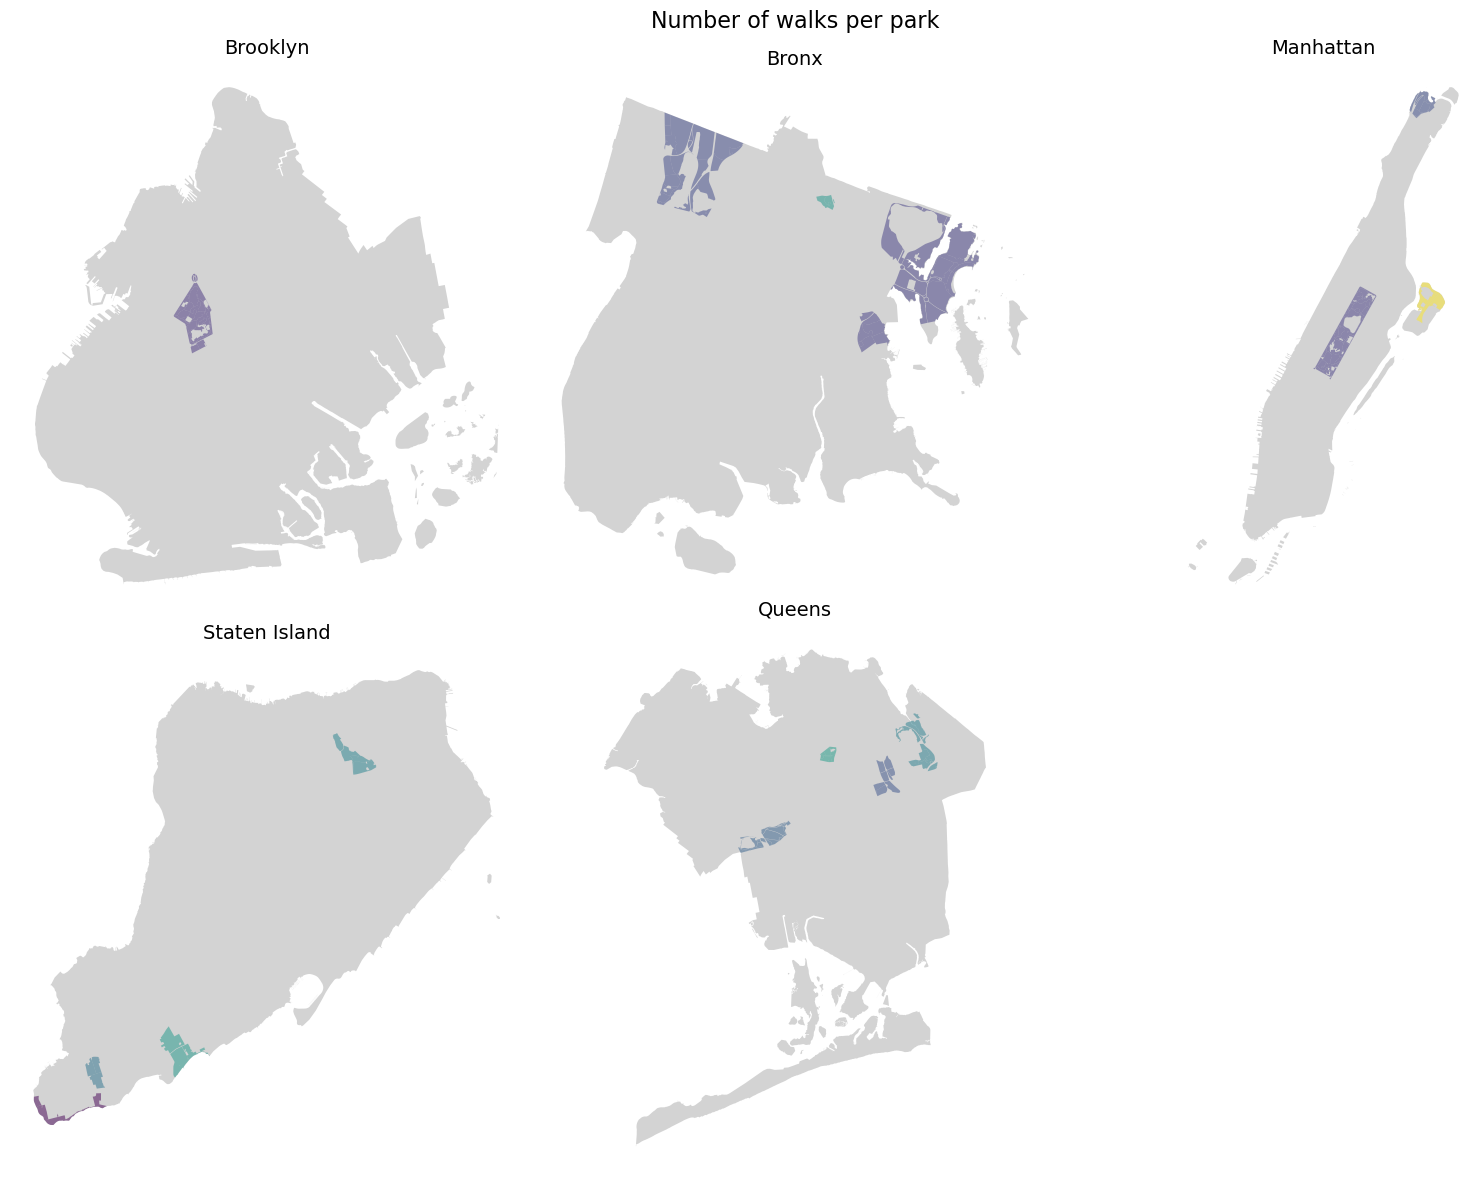

In [35]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesPerWalk', ax=ax,
                                                legend=False, alpha=.5, 
                                                vmin=parks_viz['SpeciesPerWalk'].min(),
                                                vmax=parks_viz['SpeciesPerWalk'].max())
    ax.set_title(boro, fontsize=14)
    ax.set_axis_off()
axs[1][2].remove()
plt.suptitle('Number of walks per park', fontsize=16)
plt.tight_layout()
plt.savefig('./img/parks_species_per_walk.png')
;

''

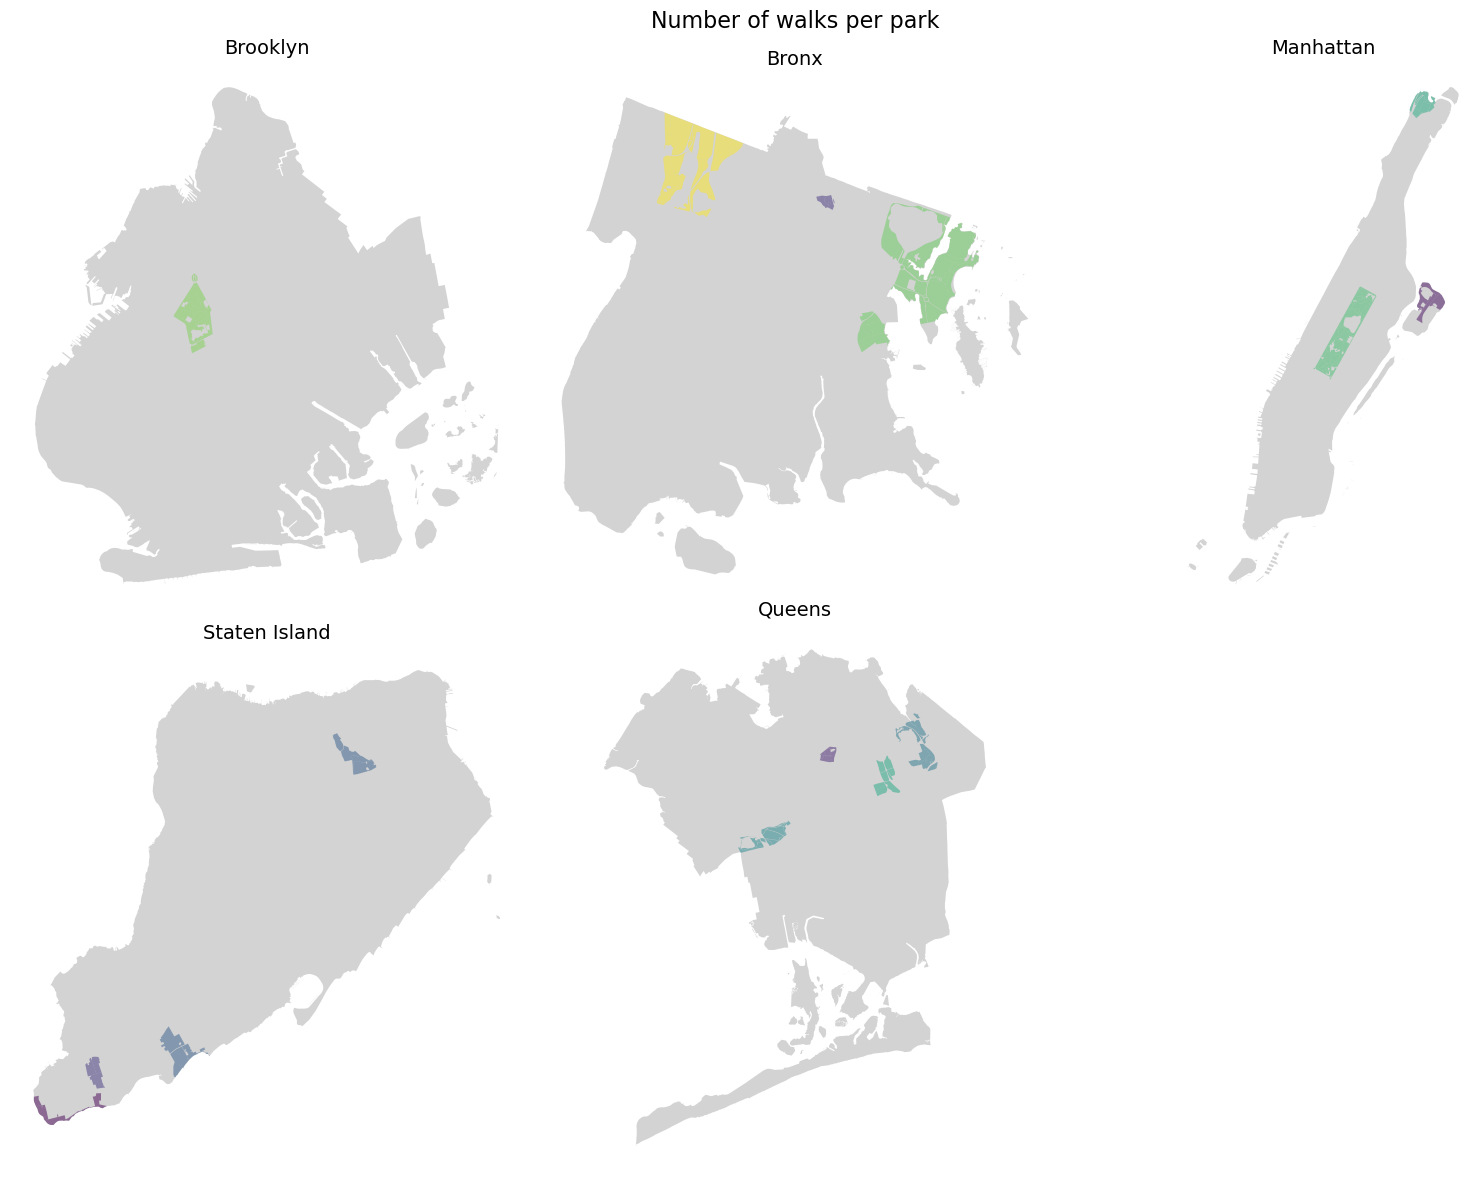

In [30]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='WalkCounts', ax=ax,
                                                legend=False, alpha=.5, 
                                                vmin=parks_viz['WalkCounts'].min(),
                                                vmax=parks_viz['WalkCounts'].max())
    ax.set_title(boro, fontsize=14)
    ax.set_axis_off()
axs[1][2].remove()
plt.suptitle('Number of walks per park', fontsize=16)
plt.tight_layout()
plt.savefig('./img/parks_walks_per_park.png')
;